## artificial neural network classifier 
After preprocessing, every match becomes a numerical vector.

Conceptually, the network receives inputs such as:

Ranking difference
Points difference
Previous win-rate difference
Recent-form difference
Surface win-rate difference
Head-to-head information
Tournament surface
Tournament round

The network contains:

Input layer → Hidden layer or layers → Output

Each hidden neuron calculates a weighted combination of its inputs, adds a bias and applies an activation function. During training, the weights are repeatedly adjusted to reduce classification error.

The goal of this notebook is to use an Artificial Neural Network
to predict whether Player 1 wins the match.

The network receives the numerical pre-match features created in the
previous notebooks. The output is a probability between 0 and 1.

A value close to 1 means that the network expects Player 1 to win,
while a value close to 0 means that it expects Player 2 to win.

In [2]:
from pathlib import Path 

import numpy as np 
import pandas as pd 
import tensorflow as tf

import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.preprocessing import StandardScaler 

from sklearn.metrics import (
    accuracy_score, 
    balanced_accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    roc_auc_score,
    log_loss,
    confusion_matrix, 
    classification_report
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation 
from tensorflow.keras import Input 
from tensorflow.keras import optimizers

In [3]:
np.random.seed(42)
tf.random.set_seed(42)

In [4]:
PROCESSED_DATA_DIR = Path("../data/processed")

input_file = (
    PROCESSED_DATA_DIR / "feature_split_matches.csv"
)

matches = pd.read_csv(
    input_file, parse_dates = ["Date"]
)

matches = matches.sort_values(
    by=["Date", "MatchID"]
).reset_index(drop=True)

print("Dataset shape:", matches.shape)
print(matches["DataSplit"].value_counts())


Dataset shape: (26536, 49)
DataSplit
Training      18810
Test           5119
Validation     2607
Name: count, dtype: int64


In [5]:
## create copies of the sets 
train_data = matches.loc[
    matches["DataSplit"] == "Training"
].copy()

validation_data = matches.loc[
    matches["DataSplit"] == "Validation"
].copy()

test_data = matches.loc[
    matches["DataSplit"] == "Test"
].copy()

## check the periods
print(
    "Training:", 
    train_data["Date"].min(),
    "-",
    train_data["Date"].max()
)

print(
    "Validating:", 
    validation_data["Date"].min(),
    "-",
    validation_data["Date"].max()
)

print(
    "Testing:", 
    test_data["Date"].min(),
    "-",
    test_data["Date"].max()
)


Training: 2015-01-05 00:00:00 - 2022-11-20 00:00:00
Validating: 2023-01-01 00:00:00 - 2023-12-31 00:00:00
Testing: 2024-01-01 00:00:00 - 2025-11-16 00:00:00


In [6]:
assert(
    train_data["Date"].max() < validation_data["Date"].min()
)

assert(
    validation_data["Date"].max() < test_data["Date"].min()
)

print("Chrnological order is mantained.")

Chrnological order is mantained.


In [7]:
## ANN receives a numerical matrix 
# --> for now it uses only numerical features 

numeric_features = [
    "Player1Rank",
    "Player2Rank",
    "Player1Points",
    "Player2Points",

    "Player1MatchesBefore",
    "Player2MatchesBefore",
    "ExperienceDifference",

    "Player1WinRateBefore",
    "Player2WinRateBefore",
    "WinRateDifference",

    "Player1Recent5WinRate",
    "Player2Recent5WinRate",
    "Recent5WinRateDifference",

    "Player1SurfaceMatchesBefore",
    "Player2SurfaceMatchesBefore",

    "Player1SurfaceWinRateBefore",
    "Player2SurfaceWinRateBefore",
    "SurfaceWinRateDifference",

    "H2HMatchesBefore",
    "Player1H2HWinRateBefore",
    "Player2H2HWinRateBefore",
    "DifferenceH2HWinRateBefore",

    "Player1DaysSinceLastMatch",
    "Player2DaysSinceLastMatch",

    "RankDifference",
    "PointsDifference"
]

missing_columns = [
    column 
    for column in numeric_features
    if column not in matches.columns
]

print("Missing columns:", missing_columns)

Missing columns: []


In [8]:
## create input and outputs

X_train = train_data[numeric_features].copy()
X_validation = validation_data[numeric_features].copy()

y_train = train_data["Player1Won"].to_numpy()
y_validation = validation_data["Player1Won"].to_numpy()

print("Training X:", X_train.shape)
print("Training y:", y_train.shape)

print("Validating X:", X_validation.shape)
print("Validating y:", y_validation.shape)

Training X: (18810, 26)
Training y: (18810,)
Validating X: (2607, 26)
Validating y: (2607,)


Player1DaysSinceLastMatch, Player2DaysSinceLastMatch 
Values that have missing values, bc a first appearance has no previous match, so the number of days cannot be calculated. The best solution us to replace the missing values with the median calculated from the training set. 

Why use training medians for validation?

We must not calculate the replacement values from validation data.

The validation set represents future matches. Using its values to prepare the training process would give us information from the future.

Therefore:

training_medians = train_X.median()

learns the replacement values from training data only.

Those same medians are then applied to validation data.

## validation_X.isna().sum()
means:
How many missing values are there in each column?
While:
## validation_X.isna().sum().sum()
means:
How many missing values are there in the entire DataFrame?

In [9]:
training_medians = X_train.median()

X_train = X_train.fillna(training_medians)

X_validation = X_validation.fillna(training_medians)

## chack that no missing values remains 
print(
    "Missing training_values:", 
    X_train.isna().sum().sum()
)

print(
    "Missing validation values:", 
    X_validation.isna().sum().sum()
)

Missing training_values: 0
Missing validation values: 0


For the training set:
## normalizer.fit_transform(train_X)
does two things:
calculates the training mean and standard deviation;
standardises the training values.

For validation:
## normalizer.transform(validation_X)
uses the mean and standard deviation already calculated from training.

We must not write:
normalizer.fit_transform(validation_X)
because that would prepare validation data using its own distribution.

In [10]:
# standardize the input 

normalizer = StandardScaler()

X_train = normalizer.fit_transform(X_train)
X_validation = normalizer.transform(X_validation)

print(
    pd.DataFrame(X_train).describe().T.head(10)
)

     count          mean       std       min       25%       50%       75%  \
0  18810.0  6.648353e-17  1.000027 -0.793058 -0.538951 -0.229603  0.190227   
1  18810.0  7.101650e-17  1.000027 -0.786692 -0.525388 -0.220532  0.182312   
2  18810.0  1.510989e-18  1.000027 -0.830961 -0.491406 -0.329513  0.040528   
3  18810.0 -4.381869e-17  1.000027 -0.832648 -0.486083 -0.320054  0.035109   
4  18810.0  0.000000e+00  1.000027 -1.139764 -0.818762 -0.276378  0.598076   
5  18810.0  9.670332e-17  1.000027 -1.125410 -0.816726 -0.287553  0.572353   
6  18810.0  3.777473e-18  1.000027 -3.920863 -0.482052  0.001086  0.484225   
7  18810.0  2.750001e-16  1.000027 -3.317998 -0.637339 -0.106858  0.635232   
8  18810.0 -6.882556e-16  1.000027 -3.430939 -0.623094 -0.099114  0.627179   
9  18810.0 -4.532968e-18  1.000027 -3.881126 -0.654353 -0.006439  0.652866   

         max  
0  22.905215  
1  19.028912  
2   8.077883  
3   8.188260  
4   3.841308  
5   3.846609  
6   3.979876  
7   3.222076  
8   3.

In [11]:
# create first neural network 

num_instances, num_features = X_train.shape 

print("Number of training matches:", num_instances)
print("Number of input features:", num_features)

Number of training matches: 18810
Number of input features: 26


This network has:
26 input values
       ↓
16 hidden neurons with ReLU
       ↓
1 output neuron with sigmoid

## Why one output neuron?

This is a binary classification problem:
0 = Player 2 wins
1 = Player 1 wins
The output neuron produces one probability.

For example:
0.82 = estimated 82% probability that Player 1 wins
0.31 = estimated 31% probability that Player 1 wins

The predictive lesson specifically associates binary classification with a sigmoid output and binary_crossentropy.

## Why relu in the hidden layer?

The convolutional lesson introduces:
ReLU(x)=max(x,0)
and explains that it generally provides effective and relatively inexpensive convergence.
We use it in a Dense layer, not in a convolutional layer.

In [12]:
#initialize network 
model = Sequential()

#specify num of input features
model.add( Input(shape = (num_features, )))

#hidden layer
model.add( Dense(16))
model.add( Activation("relu"))

#output layer 
model.add( Dense(1))
model.add(Activation("sigmoid"))

In [13]:
model.compile(
    optimizer = optimizers.Adam(
        learning_rate=0.001),
        loss="binary_crossentropy", 
        metrics=["accuracy"]
)

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,349 (5.27 KB)

 Trainable params: 449 (1.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 900 (3.52 KB)

In [14]:
hist = model.fit(
    x = X_train, 
    y = y_train, 
    epochs = 50,
    validation_data = (
        X_validation, 
        y_validation
    ), 
    verbose=1
)

Epoch 1/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6302 - loss: 0.6420 - val_accuracy: 0.6421 - val_loss: 0.6222
Epoch 2/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6582 - loss: 0.6141 - val_accuracy: 0.6475 - val_loss: 0.6191
Epoch 3/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6622 - loss: 0.6109 - val_accuracy: 0.6483 - val_loss: 0.6176
Epoch 4/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 884us/step - accuracy: 0.6638 - loss: 0.6090 - val_accuracy: 0.6509 - val_loss: 0.6175
Epoch 5/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 930us/step - accuracy: 0.6653 - loss: 0.6077 - val_accuracy: 0.6471 - val_loss: 0.6174
Epoch 6/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 887us/step - accuracy: 0.6663 - loss: 0.6068 - val_accuracy: 0.6490 - val_loss: 0.6176
Epoch 7/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 855us/step - accuracy: 0.6673 - loss: 0.6061 - val_accuracy: 0.6494 - val_loss: 0.6181
Epoch 8/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 851us/step - accuracy: 0.6677 - loss: 0.6056 - val_ac

In [16]:
hist.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

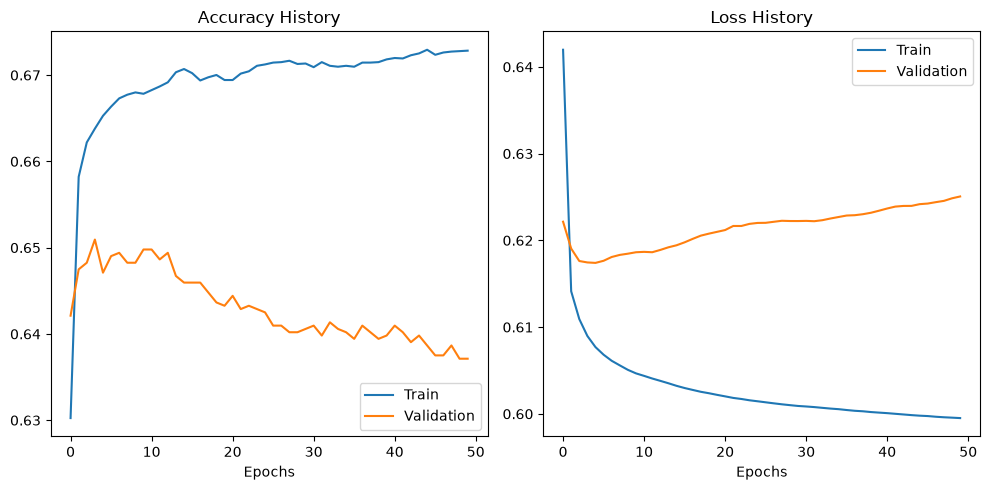

In [17]:
# plot training and validation accuracy 

%matplotlib inline 

fig, axes = plt.subplots(
    nrows=1, 
    ncols=2, 
    figsize=(10, 5)
)

axes[0].plot(hist.history["accuracy"], label="Train")
axes[0].plot(hist.history["val_accuracy"], label="Validation")

axes[0].set_title("Accuracy History")
axes[0].set_xlabel("Epochs")
axes[0].legend()

axes[1].plot(hist.history["loss"], label="Train")
axes[1].plot(hist.history["val_loss"], label="Validation")

axes[1].set_title("Loss History")
axes[1].set_xlabel("Epochs")
axes[1].legend()

plt.tight_layout()
plt.show()


In [18]:
validation_loss, validation_accuracy = (
    model.evaluate(
        X_validation, 
        y_validation, 
        verbose=0
    )
)

print("Validation loss:", validation_loss)
print("Validation accuracy:", validation_accuracy)

Validation loss: 0.6250609755516052
Validation accuracy: 0.6371307969093323


In [19]:
validation_probabilities = model.predict(
    X_validation, 
    verbose=0
)

validation_probabilities = (
    validation_probabilities.reshape(-1)
)

In [20]:
validation_predictions = (
    validation_probabilities >= 0.5
).astype(int)

In [21]:
prediction_example = pd.DataFrame(
    {
        "ProbabilityPlayer1Wins": validation_probabilities[:10],
        "PredictedClass": validation_predictions[:10],
        "TrueClass": y_validation[:10]
    }
)

prediction_example

,ProbabilityPlayer1Wins,PredictedClass,TrueClass
0,0.592533,1,0
1,0.470852,0,0
2,0.512192,1,0
3,0.682939,1,1
4,0.648957,1,0
5,0.709119,1,0
6,0.803735,1,0
7,0.485361,0,1
8,0.355162,0,0
9,0.548357,1,0


In [22]:
initial_results = pd.DataFrame(
    {
        "Model": ["Initial ANN"],
        "Accuracy": [
            accuracy_score(y_validation, validation_predictions)
        ], 
        "BalancedAccuracy": [
            balanced_accuracy_score(y_validation, validation_predictions)
        ], 
        "Precision": [
            precision_score(y_validation, validation_predictions, zero_division=0)
        ], 
        "Recall": [
            recall_score(y_validation, validation_predictions, zero_division=0)
        ], 
        "F1": [
            f1_score(y_validation, validation_predictions, zero_division=0)
        ], 
        "ROC_AUC": [
            roc_auc_score(y_validation, validation_probabilities)
        ], 
        "LogLoss": [
            log_loss(y_validation, validation_probabilities)
        ]
    }
)

initial_results

,Model,Accuracy,BalancedAccuracy,Precision,Recall,F1,ROC_AUC,LogLoss
0,Initial ANN,0.637131,0.637762,0.611069,0.650525,0.63018,0.699712,0.625061


In [23]:
print("Classification Report")

print(
    classification_report(
        y_validation, 
        validation_predictions, 
        target_names=[
            "Player 2 wins", 
            "Player 1 wins"
        ], 
        zero_division=0
    )
)

Classification Report
               precision    recall  f1-score   support

Player 2 wins       0.66      0.62      0.64      1368
Player 1 wins       0.61      0.65      0.63      1239

     accuracy                           0.64      2607
    macro avg       0.64      0.64      0.64      2607
 weighted avg       0.64      0.64      0.64      2607



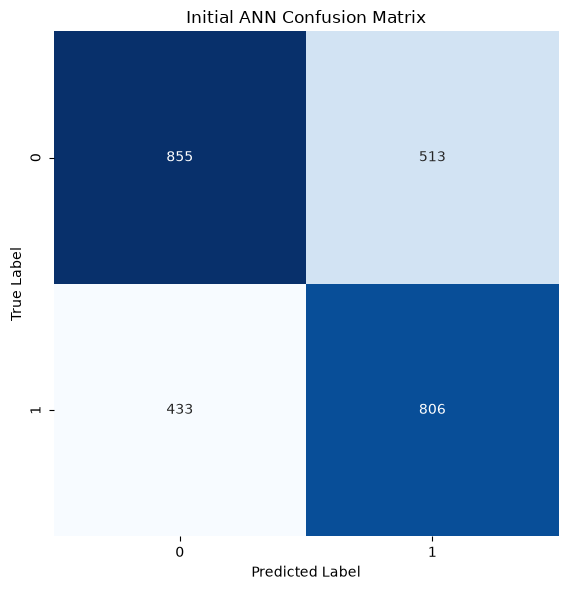

In [24]:
matrix = confusion_matrix(
    y_validation, 
    validation_predictions
)

fig, axes = plt.subplots(
    figsize=(6, 6),
    tight_layout=True
)

sns.heatmap(
    matrix,
    square=True, 
    annot=True,
    fmt="d", 
    cbar=False, 
    cmap="Blues"
)

axes.set_xlabel("Predicted Label")

axes.set_ylabel("True Label")

axes.set_title("Initial ANN Confusion Matrix")

plt.show()

The project requires parameter tuning. We will not use an advanced automatic search. Instead, we will test a small number of networks created using ideas directly taken from the lessons.

We will vary:

hidden-layer size;
number of hidden layers;
hidden activation;
learning rate;
number of epochs.

In [25]:
def build_model(
    hidden_layers, 
    hidden_activation, 
    learning_rate
):
    #initialize network 
    current_model = Sequential()
    
    #input 
    current_model.add(Input(shape=(num_features,)))
    
    #hidden layer 
    for number_of_neurons in hidden_layers: 
        
        current_model.add(Dense(number_of_neurons))
        current_model.add(Activation(hidden_activation))
        
    #output 
    current_model.add(Dense(1))
    current_model.add(Activation("sigmoid"))
    
    #finalize the network 
    current_model.compile(
        optimizer=optimizers.Adam(
            learning_rate=learning_rate
        ), 
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    
    return current_model

In [26]:
configurations = [
    {
        "name" : "ANN 8 sigmoid",
        "hidden_layers": [8], 
        "activation": "sigmoid", 
        "learning_rate": 0.01, 
        "epochs": 50
    }, 
    
    {
        "name": "ANN 16 relu",
        "hidden_layers": [16], 
        "activation": "relu", 
        "learning_rate": 0.001, 
        "epochs": 50
    },
    
    {
        "name": "ANN 32 relu", 
        "hidden_layers": [32], 
        "activation": "relu", 
        "learning_rate": 0.001, 
        "epochs": 50
    }, 
    
    {
        "name": "ANN 32-16 relu", 
        "hidden_layers": [32, 16], 
        "activation": "relu", 
        "learning_rate": 0.001, 
        "epochs": 50
    }, 
    
    {
        "name": "ANN 32-16 slow", 
        "hidden_layers": [32, 16], 
        "activation": "relu",
        "learning_rate": 0.0005, 
        "epochs": 100
    }
    
]

In [27]:
tuning_results = []

trained_models = {}
training_histories = {}

for configuration in configurations: 
    
    print("\nTraining:", configuration["name"])
    
    #reset the random seed
    np.random.seed(42)
    tf.random.set_seed(42)
    
    current_model = build_model(
        hidden_layers=(
            configuration["hidden_layers"]
        ), 
        hidden_activation=(
            configuration["activation"]
        ), 
        learning_rate=(
            configuration["learning_rate"]
        )
    )
    
    current_history = current_model.fit(
        x = X_train, 
        y = y_train, 
        epochs= configuration["epochs"],
        validation_data=(
            X_validation, 
            y_validation
        ),
        verbose=0
    )

    current_probabilities = (
        current_model.predict(
            X_validation, 
            verbose=0
        ).reshape(-1)
    )

    current_predictions = (
        current_probabilities >= 0.5
    ).astype(int)

    current_accuracy = accuracy_score(
        y_validation, 
        current_predictions
    )

    current_balanced_accuracy = (
        balanced_accuracy_score(
            y_validation, 
            current_predictions
        )
    )

    current_precision = precision_score(
        y_validation, 
        current_predictions, 
        zero_division=0
    )

    current_recall = recall_score(
        y_validation, 
        current_predictions, 
        zero_division=0
    )

    current_f1 = f1_score(
        y_validation, 
        current_predictions, 
        zero_division=0
    )

    current_roc_auc = roc_auc_score(
        y_validation, 
        current_probabilities
    )

    current_log_loss = log_loss(
        y_validation, 
        current_probabilities
    )

    tuning_results.append(
        {
            "Model": configuration["name"], 
            "HiddenLayers": str( configuration["hidden_layers"]), 
            "Activation": configuration["activation"], 
            "LearningRate": configuration["learning_rate"], 
            "Epochs": configuration["epochs"], 
            "Accuracy": current_accuracy, 
            "BalancedAccuracy": current_balanced_accuracy, 
            "Precision": current_precision, 
            "Recall": current_recall, 
            "F1": current_f1, 
            "ROC_AUC": current_roc_auc, 
            "LogLoss": current_log_loss
        }
    )

    trained_models[
        configuration["name"]
    ] = current_model

    training_histories[
        configuration["name"]
    ]= current_history

    print("Validation accuracy:", round(current_accuracy, 4))


Training: ANN 8 sigmoid
Validation accuracy: 0.6306

Training: ANN 16 relu
Validation accuracy: 0.6279

Training: ANN 32 relu
Validation accuracy: 0.6318

Training: ANN 32-16 relu
Validation accuracy: 0.6133

Training: ANN 32-16 slow
Validation accuracy: 0.6344


In [28]:
tuning_results = pd.DataFrame(tuning_results)

tuning_results = tuning_results.sort_values(
    by=[
        "Accuracy", "ROC_AUC"
    ], 
    ascending=[False, False]
).reset_index(drop=True)

tuning_results 

,Model,HiddenLayers,Activation,LearningRate,Epochs,Accuracy,BalancedAccuracy,Precision,Recall,F1,ROC_AUC,LogLoss
0,ANN 32-16 slow,"[32, 16]",relu,0.0005,100,0.634446,0.635052,0.608498,0.647296,0.627298,0.690651,0.638322
1,ANN 32 relu,[32],relu,0.0010,50,0.631761,0.633140,0.602649,0.661017,0.630485,0.695929,0.629273
2,ANN 8 sigmoid,[8],sigmoid,0.0100,50,0.630610,0.632576,0.599281,0.672316,0.633701,0.691879,0.635576
3,ANN 16 relu,[16],relu,0.0010,50,0.627925,0.628001,0.604183,0.629540,0.616601,0.696298,0.626722
4,ANN 32-16 relu,"[32, 16]",relu,0.0010,50,0.613349,0.614797,0.584615,0.644068,0.612903,0.676906,0.651619


In [29]:
best_model_name = (tuning_results.iloc[0]["Model"])
best_model = trained_models[best_model_name]
best_history = training_histories[best_model_name]

print("Selected model:", best_model_name)

Selected model: ANN 32-16 slow


In [30]:
best_validation_probabilities = (
    best_model.predict(
        X_validation, 
        verbose=0
    ).reshape(-1)
)

best_validation_predictions = (
    best_validation_probabilities >= 0.5 
).astype(int)

print(
    classification_report(
        y_validation, 
        best_validation_predictions, 
        target_names = [
            "Player 2 wins", 
            "Player 1 wins"
        ], 
        zero_division = 0
    )
)

               precision    recall  f1-score   support

Player 2 wins       0.66      0.62      0.64      1368
Player 1 wins       0.61      0.65      0.63      1239

     accuracy                           0.63      2607
    macro avg       0.63      0.64      0.63      2607
 weighted avg       0.64      0.63      0.63      2607



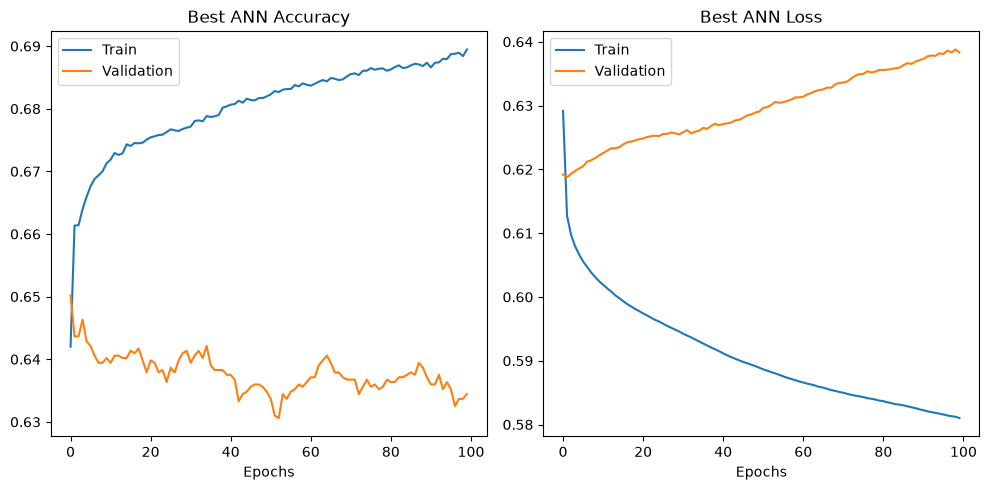

In [31]:
fig, axes = plt.subplots(
    nrows=1, 
    ncols=2, 
    figsize=(10, 5)
)

axes[0].plot(best_history.history["accuracy"], label="Train")
axes[0].plot(best_history.history["val_accuracy"], label="Validation")

axes[0].set_title("Best ANN Accuracy")
axes[0].set_xlabel("Epochs")
axes[0].legend()

axes[1].plot(best_history.history["loss"], label="Train")
axes[1].plot(best_history.history["val_loss"], label="Validation")

axes[1].set_title("Best ANN Loss")
axes[1].set_xlabel("Epochs")
axes[1].legend()

plt.tight_layout()
plt.show()

In [32]:
## compare with the baseline 
baseline_file = (PROCESSED_DATA_DIR / "validation_baseline.csv")
baseline_results = pd.read_csv(baseline_file)

best_ann_result = tuning_results.loc[
    [0], 
    [
        "Model",
        "Accuracy",
        "BalancedAccuracy",
        "Precision",
        "Recall",
        "F1"  
    ]
].copy()

# combine baseline results and ANN result
comparison_results = pd.concat(
    [
        baseline_results[
            [
                "Model",
                "Accuracy",
                "BalancedAccuracy",
                "Precision",
                "Recall",
                "F1"
            ]
        ],
        best_ann_result
    ],
    ignore_index=True
)

comparison_results = (
    comparison_results
    .sort_values(
        by="Accuracy", ascending=False
    ).reset_index(drop=True)
)

comparison_results


,Model,Accuracy,BalancedAccuracy,Precision,Recall,F1
0,Better-ranked player,0.640199,0.640648,0.614973,0.649718,0.631868
1,ANN 32-16 slow,0.634446,0.635052,0.608498,0.647296,0.627298
2,More ranking points,0.626007,0.626592,0.600152,0.638418,0.618694
3,Higher previous win rate,0.607979,0.608424,0.582635,0.617433,0.599530
4,Better recent win rate,0.549674,0.557169,0.519219,0.708636,0.599317
5,Majority class,0.524741,0.500000,0.000000,0.000000,0.000000


In [33]:
# create an analysis table
ann_validation_analysis = (
    validation_data [
        [   
            "MatchID",
            "Date",
            "Tournament",
            "Surface",
            "Round",
            "Player1",
            "Player2",
            "Player1Rank",
            "Player2Rank",
            "RankDifference",
            "WinRateDifference",
            "Recent5WinRateDifference",
            "SurfaceWinRateDifference",
            "Player1Won"
        ]
    ].copy()
)

In [34]:
# add the ann results
ann_validation_analysis[
    "ANNProbability"
] = best_validation_probabilities

ann_validation_analysis[
    "ANNPrediction"
] = best_validation_predictions

ann_validation_analysis[
    "Correct"
] = (
    ann_validation_analysis[
        "ANNPrediction"
    ] == ann_validation_analysis[
        "Player1Won"
    ]
)

#calculate prediction confidence
ann_validation_analysis[
    "Confidence"
] = np.maximum(
    ann_validation_analysis[
        "ANNProbability"
    ],
    1 - ann_validation_analysis["ANNProbability"]
)

#display the ten most confident errors 
most_confident_errors = (
    ann_validation_analysis.loc[
        ann_validation_analysis[
            "Correct"
        ] == False
    ].sort_values(
        by="Confidence", ascending=False
    )
)

most_confident_errors.head(10)


,MatchID,Date,Tournament,Surface,Round,Player1,Player2,Player1Rank,Player2Rank,RankDifference,WinRateDifference,Recent5WinRateDifference,SurfaceWinRateDifference,Player1Won,ANNProbability,ANNPrediction,Correct,Confidence
20516,20516,2023-07-25,Atlanta Open,Hard,1st Round,Nishikori K.,Thompson J.,439.0,63.0,-376.0,0.274554,0.0,0.258924,1,0.034274,0,False,0.965726
20062,20062,2023-05-30,French Open,Clay,1st Round,Seyboth Wild T.,Medvedev D.,172.0,2.0,-170.0,-0.318952,-0.8,-0.118598,1,0.046931,0,False,0.953069
20161,20161,2023-06-15,Rosmalen Grass Court Championships,Grass,2nd Round,Mannarino A.,Medvedev D.,52.0,3.0,-49.0,-0.226512,-0.4,-0.061741,1,0.052678,0,False,0.947322
21209,21209,2023-10-19,Japan Open Tennis Championships,Hard,2nd Round,Mochizuki S.,Fritz T.,215.0,10.0,-205.0,-0.392358,-0.4,-0.372372,1,0.067368,0,False,0.932631
19935,19935,2023-05-15,Internazionali BNL d'Italia,Clay,3rd Round,Alcaraz C.,Marozsan F.,2.0,135.0,133.0,0.031690,0.0,0.073529,0,0.931397,1,False,0.931397
19753,19753,2023-04-21,Srpska Open,Clay,Quarterfinals,Djokovic N.,Lajovic D.,1.0,70.0,69.0,0.433021,0.0,0.311874,0,0.925884,1,False,0.925884
19137,19137,2023-02-14,Delray Beach Open,Hard,1st Round,Sock J.,Pecotic M.,143.0,784.0,641.0,0.073991,-0.1,0.087500,0,0.922875,1,False,0.922875
19127,19127,2023-02-14,Argentina Open,Clay,1st Round,Diaz Acosta F.,Coria F.,191.0,49.0,-142.0,-0.186782,-0.4,-0.282258,1,0.087351,0,False,0.912649
19175,19175,2023-02-16,ABN AMRO World Tennis Tournament,Hard,2nd Round,Sinner J.,Tsitsipas S.,14.0,3.0,-11.0,0.011202,0.0,0.051604,1,0.089571,0,False,0.910429
20694,20694,2023-08-08,Canadian Open,Hard,1st Round,Evans D.,Diallo G.,21.0,141.0,120.0,0.300000,1.0,0.288961,0,0.908847,1,False,0.908847


In [35]:
# create the folder to save the results 
RESULTS_DIR = Path("../results")
MODELS_DIR = Path("../models")

RESULTS_DIR.mkdir(
    parents = True,
    exist_ok=True
)

MODELS_DIR.mkdir(
    parents=True, 
    exist_ok=True
)

tuning_results.to_csv(
    RESULTS_DIR / "ann_tuning_results.csv",
    index=False
)

ann_validation_analysis.to_csv(
    RESULTS_DIR / "ann_validation_predictions.csv",
    index=False
)

best_model.save(
    MODELS_DIR / "best_ann_validation.keras"
)

In [36]:
## to delete 
print("ANN tuning results:")

print(
    tuning_results[
        [
            "Model",
            "HiddenLayers",
            "Activation",
            "LearningRate",
            "Epochs",
            "Accuracy",
            "BalancedAccuracy",
            "F1",
            "ROC_AUC",
            "LogLoss"
        ]
    ]
)

ANN tuning results:
            Model HiddenLayers Activation  LearningRate  Epochs  Accuracy  \
0  ANN 32-16 slow     [32, 16]       relu        0.0005     100  0.634446   
1     ANN 32 relu         [32]       relu        0.0010      50  0.631761   
2   ANN 8 sigmoid          [8]    sigmoid        0.0100      50  0.630610   
3     ANN 16 relu         [16]       relu        0.0010      50  0.627925   
4  ANN 32-16 relu     [32, 16]       relu        0.0010      50  0.613349   

   BalancedAccuracy        F1   ROC_AUC   LogLoss  
0          0.635052  0.627298  0.690651  0.638322  
1          0.633140  0.630485  0.695929  0.629273  
2          0.632576  0.633701  0.691879  0.635576  
3          0.628001  0.616601  0.696298  0.626722  
4          0.614797  0.612903  0.676906  0.651619  


In [37]:
print(
    "Selected ANN:",
    best_model_name
)

print("\nANN and baseline comparison:")

print(
    comparison_results
)

Selected ANN: ANN 32-16 slow

ANN and baseline comparison:
                      Model  Accuracy  BalancedAccuracy  Precision    Recall  \
0      Better-ranked player  0.640199          0.640648   0.614973  0.649718   
1            ANN 32-16 slow  0.634446          0.635052   0.608498  0.647296   
2       More ranking points  0.626007          0.626592   0.600152  0.638418   
3  Higher previous win rate  0.607979          0.608424   0.582635  0.617433   
4    Better recent win rate  0.549674          0.557169   0.519219  0.708636   
5            Majority class  0.524741          0.500000   0.000000  0.000000   

         F1  
0  0.631868  
1  0.627298  
2  0.618694  
3  0.599530  
4  0.599317  
5  0.000000  


In [38]:
print(
    most_confident_errors[
        [
            "Date",
            "Player1",
            "Player2",
            "Player1Won",
            "ANNPrediction",
            "ANNProbability",
            "Confidence"
        ]
    ].head(10)
)

            Date          Player1       Player2  Player1Won  ANNPrediction  \
20516 2023-07-25     Nishikori K.   Thompson J.           1              0   
20062 2023-05-30  Seyboth Wild T.   Medvedev D.           1              0   
20161 2023-06-15     Mannarino A.   Medvedev D.           1              0   
21209 2023-10-19     Mochizuki S.      Fritz T.           1              0   
19935 2023-05-15       Alcaraz C.   Marozsan F.           0              1   
19753 2023-04-21      Djokovic N.    Lajovic D.           0              1   
19137 2023-02-14          Sock J.    Pecotic M.           0              1   
19127 2023-02-14   Diaz Acosta F.      Coria F.           1              0   
19175 2023-02-16        Sinner J.  Tsitsipas S.           1              0   
20694 2023-08-08         Evans D.     Diallo G.           0              1   

       ANNProbability  Confidence  
20516        0.034274    0.965726  
20062        0.046931    0.953069  
20161        0.052678    0.947322